# 01 · Data & Tournament Landscape

A professional tour of the canonical match table that powers every model:
data volume and composition, scoring dynamics (including the home-advantage
trend), the WC-2026 group draw and which *groups of death* stand out, and the
historical coverage that drives rating reliability.

**Data:** `data/interim/matches_unified.csv` (run `import_kaggle_history.py` and
`bootstrap_historical_data.py` first).

In [1]:
import nb_style as nbs
nbs.apply_theme()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.data_loader import DataLoader

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

matches = DataLoader().load_matches()
matches["date"] = pd.to_datetime(matches["date"], errors="coerce")
matches["year"] = matches["date"].dt.year
print(f"{len(matches):,} matches loaded.")

11,918 matches loaded.


## Dataset at a glance

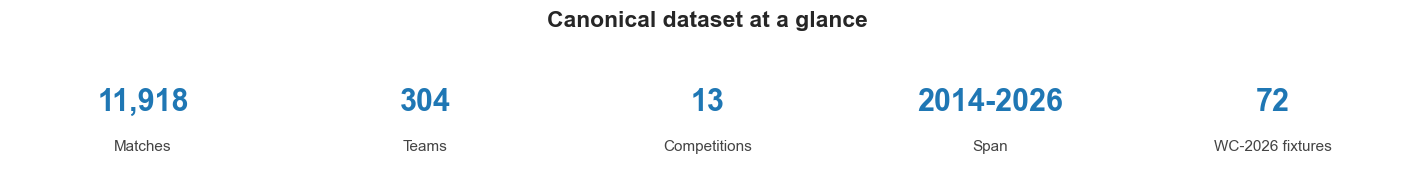

In [2]:
n_wc26 = matches[(matches["competition"] == "WC") & (matches["year"] == 2026)].shape[0]
n_teams = pd.concat([matches["team_a"], matches["team_b"]]).nunique()
nbs.kpi_header([
    ("Matches", f"{len(matches):,}"),
    ("Teams", f"{n_teams}"),
    ("Competitions", f"{matches['competition'].nunique()}"),
    ("Span", f"{matches['year'].min()}-{matches['year'].max()}"),
    ("WC-2026 fixtures", f"{n_wc26}"),
], title="Canonical dataset at a glance")

## Match volume over time

Qualifier years spike; 2020 dips with the pandemic.

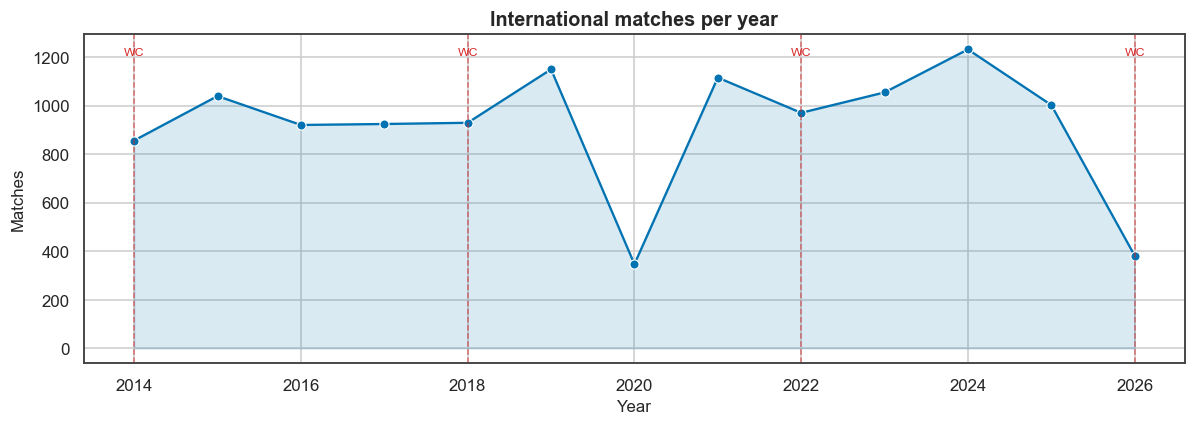

In [3]:
per_year = matches.groupby("year").size()
fig, ax = plt.subplots(figsize=(11, 4))
sns.lineplot(x=per_year.index, y=per_year.values, marker="o", ax=ax, color=nbs.PALETTE[0])
ax.fill_between(per_year.index, per_year.values, alpha=0.15, color=nbs.PALETTE[0])
for wc_year in (2014, 2018, 2022, 2026):
    if wc_year in per_year.index:
        ax.axvline(wc_year, color="#d62728", ls="--", lw=1, alpha=0.6)
        ax.text(wc_year, per_year.max() * 0.98, "WC", color="#d62728", ha="center", fontsize=8)
ax.set(title="International matches per year", xlabel="Year", ylabel="Matches")
plt.tight_layout(); plt.show()

## Competition composition

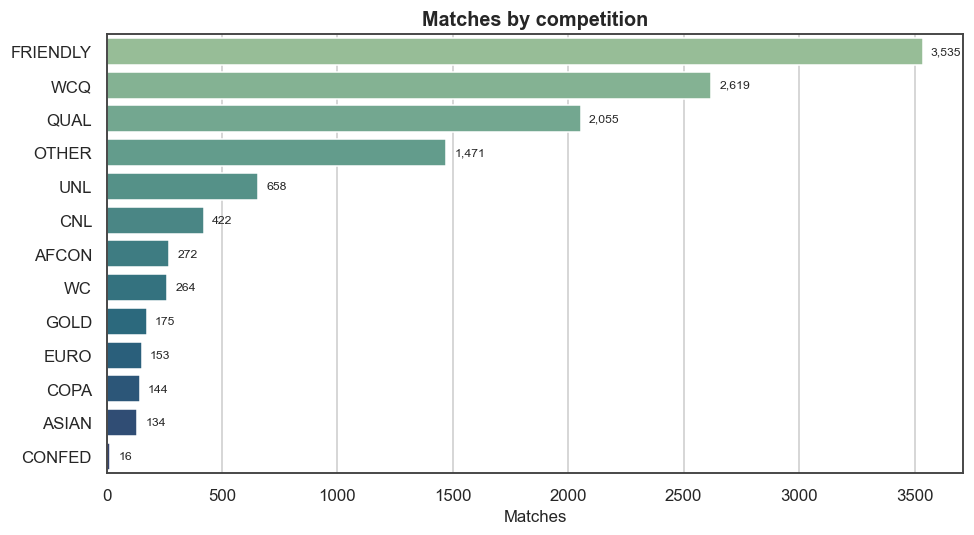

In [4]:
per_comp = matches["competition"].value_counts()
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=per_comp.values, y=per_comp.index, ax=ax, palette="crest", hue=per_comp.index, legend=False)
nbs.annotate_barh(ax, per_comp.values, fmt="{:,.0f}", pad=per_comp.max() * 0.01)
ax.set(title="Matches by competition", xlabel="Matches", ylabel="")
plt.tight_layout(); plt.show()

## Goals & home advantage

Is the home edge fading over the decade?

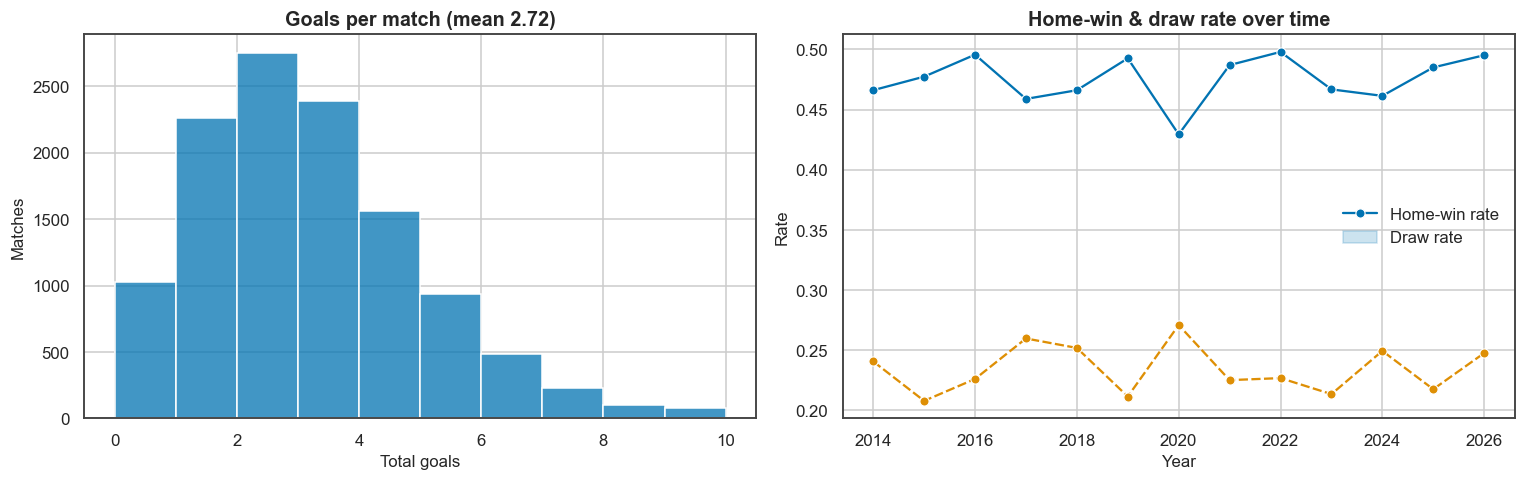

Overall home-win rate: 0.477 | draw rate: 0.231


In [5]:
played = matches.dropna(subset=["score_a", "score_b"]).copy()
played["total_goals"] = played["score_a"] + played["score_b"]
played["home_win"] = played["score_a"] > played["score_b"]
played["draw"] = played["score_a"] == played["score_b"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(played["total_goals"], bins=range(0, 11), ax=axes[0], color=nbs.PALETTE[0])
axes[0].set(title=f"Goals per match (mean {played['total_goals'].mean():.2f})",
            xlabel="Total goals", ylabel="Matches")
trend = played.groupby("year").agg(home_win_rate=("home_win", "mean"), draw_rate=("draw", "mean"))
sns.lineplot(data=trend, ax=axes[1], marker="o")
axes[1].set(title="Home-win & draw rate over time", xlabel="Year", ylabel="Rate")
axes[1].legend(["Home-win rate", "Draw rate"])
plt.tight_layout(); plt.show()
print(f"Overall home-win rate: {played['home_win'].mean():.3f} | draw rate: {played['draw'].mean():.3f}")

## Groups of death — WC-2026

Group difficulty = combined strength of the two strongest teams (two qualify).

2026-06-11 20:03:11,522 | src.ratings.elo                | INFO     | Elo fit over 11918 matches; 300 teams rated (xi=0.0000)
2026-06-11 20:03:11,873 | src.ratings.pi_rating          | INFO     | PI Rating fit over 11918 matches (xi=0.0000)
2026-06-11 20:03:12,340 | src.ratings.form_rating        | INFO     | Form rating fit over 11918 matches
2026-06-11 20:03:12,340 | src.ratings.rating_ensemble    | INFO     | Rating ensemble fit completed


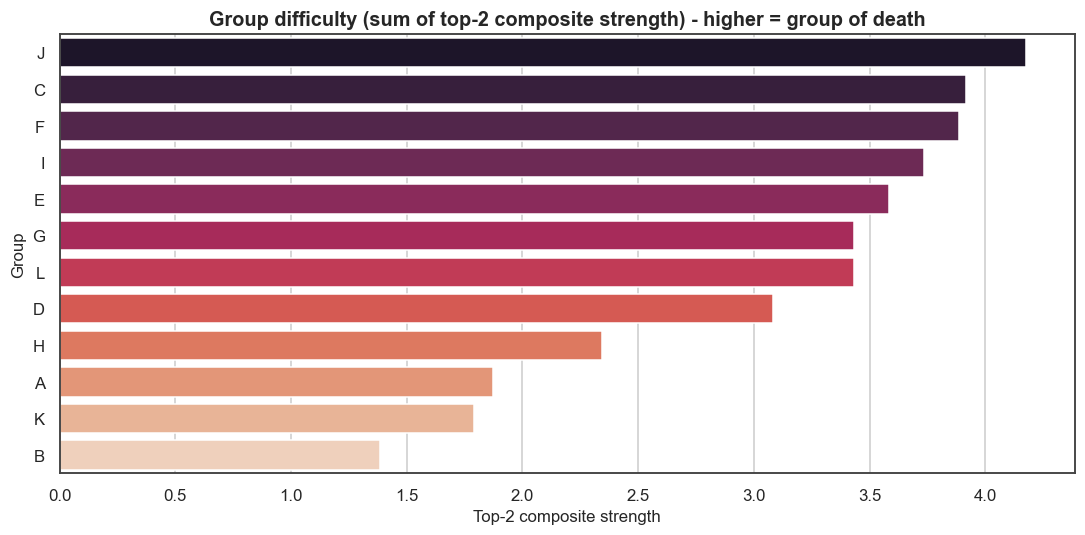

group                                            teams  mean_strength  top2_strength
    J              Algeria, Argentina, Austria, Jordan       1.611518       4.177500
    C                 Brazil, Haiti, Morocco, Scotland       1.474788       3.917200
    F              Japan, Netherlands, Sweden, Tunisia       1.339165       3.886039
    I                    France, Iraq, Norway, Senegal       1.522994       3.735275
    E           Curaçao, Ecuador, Germany, Ivory Coast       1.368739       3.585667
    G                Belgium, Egypt, Iran, New Zealand       1.358196       3.433475
    L                  Croatia, England, Ghana, Panama       1.215313       3.432473
    D       Australia, Paraguay, Turkey, United States       1.304923       3.082438
    H Cape Verde Islands, Saudi Arabia, Spain, Uruguay       1.445020       2.344964
    A       Czechia, Mexico, South Africa, South Korea       1.303343       1.870973
    K         Colombia, Congo DR, Portugal, Uzbekistan       1.63

In [6]:
from src.ratings.rating_ensemble import RatingEnsemble

composite = RatingEnsemble().fit(matches).composite_table().set_index("team")["composite_strength"]
wc = matches[(matches["competition"] == "WC") & (matches["year"] == 2026)].copy()
wc = wc[wc["group"].astype(str).str.strip().ne("")]

rows = []
for g, d in wc.groupby("group"):
    teams = sorted(set(d["team_a"]).union(d["team_b"]))
    strengths = sorted((composite.get(t, np.nan) for t in teams), reverse=True)
    rows.append({"group": g, "teams": ", ".join(teams),
                 "mean_strength": np.nanmean(strengths), "top2_strength": np.nansum(strengths[:2])})
group_df = pd.DataFrame(rows).sort_values("top2_strength", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=group_df, x="top2_strength", y="group", ax=ax, palette="rocket",
            hue="group", legend=False)
ax.set(title="Group difficulty (sum of top-2 composite strength) - higher = group of death",
       xlabel="Top-2 composite strength", ylabel="Group")
plt.tight_layout(); plt.show()
print(group_df.to_string(index=False))

## Rating reliability (data coverage)

Teams with little history get unstable ratings.

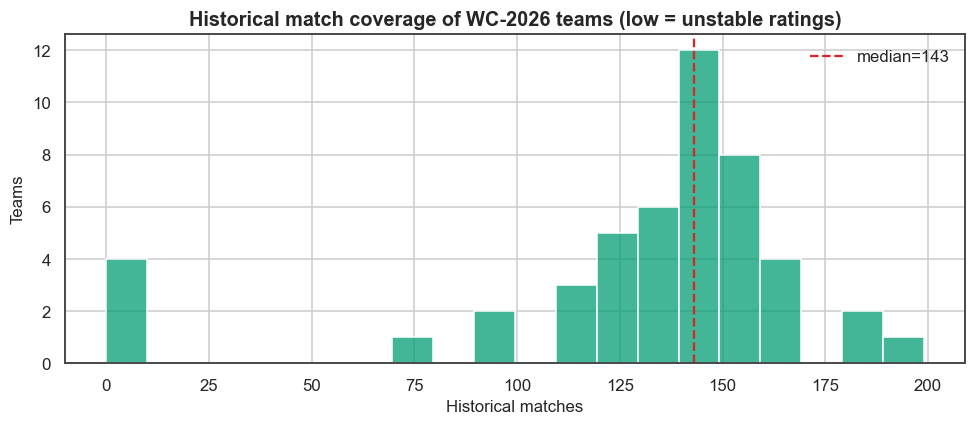

Lowest coverage (watch for unstable ratings):
              team  historical_matches
           Czechia                   0
Bosnia-Herzegovina                   0
Cape Verde Islands                   0
          Congo DR                   0
       New Zealand                  77
           Curaçao                  90
             Haiti                  94
          Scotland                 117


In [7]:
wc_teams = sorted(set(wc["team_a"]).union(wc["team_b"]))
hist = matches[matches["year"] < 2026]
cov = pd.DataFrame({
    "team": wc_teams,
    "historical_matches": [int(((hist["team_a"] == t) | (hist["team_b"] == t)).sum()) for t in wc_teams],
}).sort_values("historical_matches")
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(cov["historical_matches"], bins=20, ax=ax, color=nbs.PALETTE[2])
ax.axvline(cov["historical_matches"].median(), color="#d62728", ls="--",
           label=f"median={cov['historical_matches'].median():.0f}")
ax.set(title="Historical match coverage of WC-2026 teams (low = unstable ratings)",
       xlabel="Historical matches", ylabel="Teams"); ax.legend()
plt.tight_layout(); plt.show()
print("Lowest coverage (watch for unstable ratings):")
print(cov.head(8).to_string(index=False))

## Key findings

- **Volume & cadence:** match volume peaks in qualifier years and dips in 2020 (pandemic).
- **Scoring:** the home-win line shows whether home advantage is fading; draws hover near their long-run rate.
- **Group of death:** the top group by top-2 strength is the toughest path out of the group stage.
- **Coverage risk:** teams in the low-coverage tail carry the least reliable ratings — expect wider intervals.